# 전체 공통

In [2]:
import pandas as pd 
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import patsy
from statsmodels.stats.weightstats import DescrStatsW
from statsmodels.miscmodels.ordinal_model import OrderedModel


# 데이터 전처리

### 1. 데이터 가져오기


In [3]:
chs24 = pd.read_sas("D:\semi\data\sas\chs24_all.sas7bdat")
chs24.head(20)

,EXAMIN_YEAR,exmprs_no,age,sex,CTPRVN_CODE,PBHLTH_CODE,SPOT_NO,HSHLD_CODE,MBHLD_CODE,DONG_TY_CODE,...,cpr_02z1,cpr_03a2,cpr_03b2,cpr_04z1,sob_01z1,sob_02z1,soa_01z1,soa_06z2,soa_07z1,sod_02z3
0,b'2024',b'2024111170001700102002101',31.0,1.0,b'11',b'11700017',b'00102',b'0021',b'01',b'1',...,1.0,1.0,1.0,2.0,8.0,1.0,1.0,2.0,2.0,1.0
1,b'2024',b'2024111170001700102002102',29.0,2.0,b'11',b'11700017',b'00102',b'0021',b'02',b'1',...,2.0,8.0,8.0,2.0,8.0,1.0,1.0,3.0,2.0,1.0
2,b'2024',b'2024111170001700102002201',31.0,1.0,b'11',b'11700017',b'00102',b'0022',b'01',b'1',...,1.0,1.0,1.0,1.0,7.0,1.0,1.0,3.0,2.0,5.0
3,b'2024',b'2024111170001700102005901',37.0,1.0,b'11',b'11700017',b'00102',b'0059',b'01',b'1',...,3.0,8.0,8.0,3.0,5.0,1.0,1.0,4.0,2.0,1.0
4,b'2024',b'2024111170001700102005902',36.0,2.0,b'11',b'11700017',b'00102',b'0059',b'02',b'1',...,3.0,8.0,8.0,3.0,6.0,1.0,1.0,4.0,2.0,1.0
5,b'2024',b'2024111170001700102009601',89.0,2.0,b'11',b'11700017',b'00102',b'0096',b'01',b'1',...,3.0,8.0,8.0,3.0,5.0,1.0,2.0,88.0,8.0,3.0
6,b'2024',b'2024111170001700102017001',36.0,1.0,b'11',b'11700017',b'00102',b'0170',b'01',b'1',...,2.0,8.0,8.0,3.0,7.0,1.0,1.0,3.0,2.0,1.0
7,b'2024',b'2024111170001700102017002',32.0,2.0,b'11',b'11700017',b'00102',b'0170',b'02',b'1',...,2.0,8.0,8.0,2.0,7.0,1.0,1.0,2.0,1.0,1.0
8,b'2024',b'2024111170001700191001801',64.0,1.0,b'11',b'11700017',b'00191',b'0018',b'01',b'1',...,8.0,8.0,8.0,8.0,3.0,3.0,2.0,88.0,8.0,5.0
9,b'2024',b'2024111170001700191003101',53.0,2.0,b'11',b'11700017',b'00191',b'0031',b'01',b'1',...,2.0,8.0,8.0,2.0,8.0,1.0,1.0,2.0,1.0,1.0


### 2. 기본 데이터프레임 생성

In [4]:

df = chs24.rename(columns={

    # 신체활동 관련
    'pha_07z1': 'mod_act_days',     # 중등도 신체활동 일수
    'pha_08z1': 'mod_act_hours',    # 중등도 신체활동 시간(시)
    'pha_09z1': 'mod_act_mins',     # 중등도 신체활동 시간(분)
    'pha_04z1': 'hig_act_days',     # 고강도 신체활동 일수
    'pha_05z1': 'hig_act_hours',    # 고강도 신체활동 시간(시)
    'pha_06z1': 'hig_act_mins',     # 고강도 신체활동 시간(분)
    'phb_01z1': 'walk_days',        # 걷기 일수
    'phb_02z1': 'walk_hours',       # 걷기 시간(시)
    'phb_03z1': 'walk_mins',        # 걷기 시간(분)

    # 수면 관련
    'mtc_10z1': 'sleep_hour',       # 수면 시
    'mtc_11z1': 'sleep_min',        # 수면 분
    'mtc_13z1': 'sleep_qol',        # 전반적 수면의 질

    # 만성질환(고혈압, 당뇨)
    'hya_04z1': 'hp_diag',          # 고혈압 진단
    'dia_04z1': 'dib_diag',         # 당뇨 진단

    # BMI
    'oba_02z1': 'ht_cm',           # 키
    'oba_03z1': 'wt_kg',           # 체중
    'oba_bmi':'bmi',                # BMI

    # 흡연
    'sma_01z1': 'smoking_lifetime',  #평생 흡연 여부(추가)
    'sma_03z2': 'smoking_current',   #현재 흡연 여부(추가)
    'smb_01z1': 'cig_per_day',      #하루평균 흡연량

    # 음주
    'drb_01z3': 'alc_frq_year',     #연간 음주 빈도
    'drb_03z1': 'alc_amt',          #한 번 섭취 시 음주량
    'drb_04z1':'binge_m',           #월간 폭음 경험_남
    'drb_05z1':'binge_w',           #월간 폭음 경험_여
    
    # 가구소득
    'fma_13z1': 'household_income_yr', # 가구소득_(년)금액
    'fma_14z1': 'household_income_mth', # 가구소득_(월)금액
    'fma_24z2': 'cond_household_income_mth', # (조건부)가구소득_(월)금액

    
    # 교육 및 경제활동
    'sob_01z1': 'edu_level', # 교육 수준
    'sob_02z1': 'graduation', # 졸업 여부
    'soa_01z1': 'eco_act', # 경제활동 여부
    'soa_06z2': 'job', # 직업분류
    'sod_02z3': 'marital_status', # 혼인 상태
    
    # 의료이용
    'sra_01z3': 'unmet_need',     #미충족 의료 여부
    'sra_02z2': 'unmet_reason',           #미충족 이유
    
    # 가구형태
    'fma_19z3': 'household_type',
    
    #저녁식사후 칫솔질 여부
    'ord_01f3': 'brushing_dinner',
    
    # 연간 체중조절 경험 여부
    'obb_01z1': 'diet_year',
    
    # 우울
    'mtb_07a1':'depressive_symptom_01', # 우울증상유병_일에 대한 흥미나 재미 없음,
    'mtb_07b1':'depressive_symptom_02', # 우울증상유병_우울감 혹은 절망감,
    'mtb_07c1':'depressive_symptom_03', # 우울증상유병_잠들기 어렵거나 많이 잠,
    'mtb_07d1':'depressive_symptom_04', # 우울증상유병_피로감, 기력저하
    'mtb_07e1':'depressive_symptom_05', # 우울증상유병_식욕 저하 혹은 과식,
    'mtb_07f1':'depressive_symptom_06', # 우울증상유병_내 자신이 나쁜 사람이라는 느낌,
    'mtb_07g1':'depressive_symptom_07', # 우울증상유병_신문이나 TV 집중 어려움,
    'mtb_07h1':'depressive_symptom_08', # 우울증상유병_거동이나 말이 느림,
    'mtb_07i1':'depressive_symptom_09' # 우울증상유병_죽는 것이 낫겠다는 생각
    
 
})

df.head()

,EXAMIN_YEAR,exmprs_no,age,sex,CTPRVN_CODE,PBHLTH_CODE,SPOT_NO,HSHLD_CODE,MBHLD_CODE,DONG_TY_CODE,...,cpr_02z1,cpr_03a2,cpr_03b2,cpr_04z1,edu_level,graduation,eco_act,job,soa_07z1,marital_status
0,b'2024',b'2024111170001700102002101',31.0,1.0,b'11',b'11700017',b'00102',b'0021',b'01',b'1',...,1.0,1.0,1.0,2.0,8.0,1.0,1.0,2.0,2.0,1.0
1,b'2024',b'2024111170001700102002102',29.0,2.0,b'11',b'11700017',b'00102',b'0021',b'02',b'1',...,2.0,8.0,8.0,2.0,8.0,1.0,1.0,3.0,2.0,1.0
2,b'2024',b'2024111170001700102002201',31.0,1.0,b'11',b'11700017',b'00102',b'0022',b'01',b'1',...,1.0,1.0,1.0,1.0,7.0,1.0,1.0,3.0,2.0,5.0
3,b'2024',b'2024111170001700102005901',37.0,1.0,b'11',b'11700017',b'00102',b'0059',b'01',b'1',...,3.0,8.0,8.0,3.0,5.0,1.0,1.0,4.0,2.0,1.0
4,b'2024',b'2024111170001700102005902',36.0,2.0,b'11',b'11700017',b'00102',b'0059',b'02',b'1',...,3.0,8.0,8.0,3.0,6.0,1.0,1.0,4.0,2.0,1.0


In [5]:
df['household_type'].value_counts()

household_type
2.0     77166
4.0     69924
1.0     44166
5.0     13995
6.0     11735
7.0     10885
3.0      3765
99.0       91
77.0        1
Name: count, dtype: int64

### 3. 데이터프레임에 파생변수 컬럼 설정

In [6]:

#MET-----------------------------------------------------------------------------------------------------------------
# 신체활동 관련 파생 변수
# 걷기/중강도/고강도 총 시간(분)
df['walk_min_total'] = df['walk_days'] * (df['walk_hours'] * 60 + df['walk_mins'])
df['mod_min_total'] = df['mod_act_days'] * (df['mod_act_hours'] * 60 + df['mod_act_mins'])
df['hig_min_total'] = df['hig_act_days'] * (df['hig_act_hours'] * 60 + df['hig_act_mins'])

# 걷기만 하는 부류
df['only_walk'] = np.where((df['walk_min_total'] >= 0) & (df['mod_min_total'] == 0) & (df['hig_min_total'] == 0), 0, 1)

# 총 MET점수
df['MET'] = (df['walk_min_total'] * 3.3 +
             df['mod_min_total'] * 4.0 +    
             df['hig_min_total'] * 8.0)

# 신체활동 수준 구분(1=충분, 0=부족) : WHO 600 MET-min 기준
df['activity_level'] = np.where(df['MET'] >= 600, 1, 0)
#-----------------------------------------------------------------------------------------------------------------



#수면-----------------------------------------------------------------------------------------------------------------
# 수면 관련 파생변수
# 수면 시간(시간 단위)
df['sleep_time'] = df['sleep_hour'] + df['sleep_min'] / 60
df['sleep_time'] = df['sleep_time'].round(2)

# 수면 양호 여부(7~8시간이면 1, 그 외 0)
df['sleep_good'] = np.where(df['sleep_time'].between(7, 8, inclusive='both'), 1, 0)

# 수면 범주형
df['sleep_cat'] = pd.cut(
    df['sleep_time'],
    bins=[0, 6, 7, 8, 24],
    labels=['<6 h', '6–7 h', '7–8 h (normal)', '≥8 h'],
    right=False
)

psqi_variables1 = ['edit_mtc_03z1','mtc_04z1','mtc_05z1','mtc_06z1', 'mtc_08z1','mtc_09z1','sleep_hour','sleep_min']
psqi_variables2 = ['mtc_12a1','mtc_12b1','mtc_12c1','mtc_12d1','mtc_12e1',
                       'mtc_12f1','mtc_12g1','mtc_12h1','mtc_12i1','mtc_12j1',
                       'sleep_qol','mtc_14z1','mtc_15z1','mtc_16z1']

# ======================================================
# 1. 유효 응답 여부 판단
#    variables1: 77, 99 중 하나라도 있으면 제외
#    variables2: 7, 9 중 하나라도 있으면 제외
# ======================================================

df['PSQI'] = (
    ~df[psqi_variables1].isin([77, 99]).any(axis=1)
    &
    ~df[psqi_variables2].isin([7, 9]).any(axis=1)
    )
# any(axis = 1) >> 값 두 종류 중 하나라도 있을시 제외

# ======================================================
# 2. 시간 변수 분(min) 단위 변환 (유효 응답만)
# ======================================================
df.loc[df['PSQI'], 'sleep_latency_min'] = (
    df['mtc_05z1'] * 60 + df['mtc_06z1']
) # 수면 소요시간

df.loc[df['PSQI'], 'sleep_time_min'] = (
    df['sleep_hour'] * 60 + df['sleep_min']
) # 실제 수면시간

df.loc[df['PSQI'], 'bed_time_min'] = (
    df['edit_mtc_03z1'] * 60 + df['mtc_04z1']
) # 잠자는 시각

df.loc[df['PSQI'], 'wake_time_min'] = (
    df['mtc_08z1'] * 60 + df['mtc_09z1']
) # 기상 시각

# 자정 이후 기상 보정
df.loc[
    (df['PSQI']) &
    (df['wake_time_min'] < df['bed_time_min']),
    'wake_time_min'
] += 1440

df.loc[df['PSQI'], 'time_in_bed_min'] = (
    df['wake_time_min'] - df['bed_time_min']
)

# ======================================================
# 3. C1 ~ C7 계산 (한국판 PSQI-K 기준)
# ======================================================

# C1. 주관적 수면의 질
df.loc[df['PSQI'], 'C1'] = df['sleep_qol'] - 1

# C2. 수면 잠복기
def latency_score(x):
    if x <= 15: return 0
    elif x <= 30: return 1
    elif x <= 60: return 2
    else: return 3

df.loc[df['PSQI'], 'latency_score1'] = (
    df.loc[df['PSQI'], 'sleep_latency_min']
    .apply(latency_score)
)
df.loc[df['PSQI'], 'latency_score2'] = df['mtc_12a1'] - 1

latency_sum = df['latency_score1'] + df['latency_score2']
df.loc[df['PSQI'], 'C2'] = pd.cut(
    latency_sum, [-1, 0, 2, 4, 6], labels=[0, 1, 2, 3]
).astype(float)

# C3. 수면 시간
def sleep_duration_score(x):
    if x >= 420: return 0
    elif x >= 360: return 1
    elif x >= 300: return 2
    else: return 3

df.loc[df['PSQI'], 'C3'] = (
    df.loc[df['PSQI'], 'sleep_time_min']
    .apply(sleep_duration_score)
)

# C4. 수면 효율
df.loc[df['PSQI'], 'sleep_efficiency'] = (
    df['sleep_time_min'] / df['time_in_bed_min'] * 100
)

def efficiency_score(x):
    if x >= 85: return 0
    elif x >= 75: return 1
    elif x >= 65: return 2
    else: return 3

df.loc[df['PSQI'], 'C4'] = (
    df.loc[df['PSQI'], 'sleep_efficiency']
    .apply(efficiency_score)
)

# C5. 수면 방해
disturbance_variables = [
    'mtc_12b1','mtc_12c1','mtc_12d1','mtc_12e1',
    'mtc_12f1','mtc_12g1','mtc_12h1','mtc_12i1','mtc_12j1'
]

df.loc[df['PSQI'], 'disturbance_sum'] = (
    df.loc[df['PSQI'], disturbance_variables]
    .apply(lambda x: x - 1)
    .sum(axis=1)
)

df.loc[df['PSQI'], 'C5'] = pd.cut(
    df['disturbance_sum'], [-1, 0, 9, 18, 27], labels=[0, 1, 2, 3]
).astype(float)

# C6. 수면제 사용
df.loc[df['PSQI'], 'C6'] = df['mtc_14z1'] - 1

# C7. 주간 기능 장애
daytime_sum = (df['mtc_15z1'] - 1) + (df['mtc_16z1'] - 1)
df.loc[df['PSQI'], 'C7'] = pd.cut(
    daytime_sum, [-1, 0, 2, 4, 6], labels=[0, 1, 2, 3]
).astype(float)

# ======================================================
# 4. PSQI-K 총점 및 해석
# ======================================================
components = ['C1','C2','C3','C4','C5','C6','C7']

df.loc[df['PSQI'], 'PSQI_KR_Score'] = df[components].sum(axis=1)

def psqi_status(x):
    if pd.isna(x): return np.nan
    elif x >= 10: return '불면증/수면장애 가능성 높음'
    elif x >= 5:  return '수면의 질 저하 가능성'
    else:         return '정상'

df.loc[df['PSQI'], 'PSQI_KR_Status'] = (
    df.loc[df['PSQI'], 'PSQI_KR_Score']
    .apply(psqi_status)
)

# ======================================================
# 5. 유효하지 않은 응답자는 전부 NaN 처리
# ======================================================
df.loc[~df['PSQI'],
       components + ['PSQI_KR_Score', 'PSQI_KR_Status']] = np.nan

#-----------------------------------------------------------------------------------------------------------------



#만성질환-----------------------------------------------------------------------------------------------------------------
# 만성질환 개수 변수
# 1) NA(=9) 제거
df = df[(df['hp_diag'] != 9) & (df['dib_diag'] != 9)]

# 2) 진단 여부를 0/1로 변환
df['hp_diag_bin'] = np.where(df['hp_diag'] == 1, 1, 0)
df['dib_diag_bin'] = np.where(df['dib_diag'] == 1, 1, 0)

# 3) 만성질환 개수 계산
df['chronic_count'] = df[['hp_diag_bin', 'dib_diag_bin']].sum(axis=1)
#-----------------------------------------------------------------------------------------------------------------



#BMI-----------------------------------------------------------------------------------------------------------------
# BMI 2범주화-비정상 여부 변수(0=정상 18.5~24.9, 1=비정상)
df['bmi_abnormal'] = np.where(df['bmi'].between(18.5, 24.9), 0, 1)

# BMI 3범주화
bins = [-np.inf, 18.5, 25.0, np.inf]
labels = ['Below normal (<18.5)', 'Normal (18.5–24.9)', 'Above normal (≥25)']

df['bmi_3grp'] = pd.cut(
    df['bmi'],
    bins=bins,
    labels=labels,
    right=False
)
#-----------------------------------------------------------------------------------------------------------------


#우울 PHQ-9-----------------------------------------------------------------------------------------------------------------
# PHQ-9 총점

phq9_variables = [
    'depressive_symptom_01', # 우울증상유병_일에 대한 흥미나 재미 없음
    'depressive_symptom_02', # 우울증상유병_우울감 혹은 절망감
    'depressive_symptom_03', # 우울증상유병_잠들기 어렵거나 많이 잠
    'depressive_symptom_04', # 우울증상유병_피로감, 기력저하
    'depressive_symptom_05', # 우울증상유병_식욕 저하 혹은 과식
    'depressive_symptom_06', # 우울증상유병_내 자신이 나쁜 사람이라는 느낌
    'depressive_symptom_07', # 우울증상유병_신문이나 TV 집중 어려움
    'depressive_symptom_08', # 우울증상유병_거동이나 말이 느림
    'depressive_symptom_09' # 우울증상유병_죽는 것이 낫겠다는 생각
]

# ======================================================
# 1. 유효 응답 여부 판단 (7 또는 9 하나라도 있으면 제외)
# ======================================================
df['PHQ9'] = ~df[phq9_variables].isin([7, 9]).any(axis=1)
# any(axis = 1) >> 값 두 종류 중 하나라도 있을시 제외

# ======================================================
# 2. 문항 점수 재코딩 (1–4 → 0–3)
# ======================================================
for v in phq9_variables:
    df.loc[df['PHQ9'], f'{v}_score'] = df[v] - 1

# ======================================================
# 3. PHQ-9 총점 (0–27)
# ======================================================
score_vars = [f'{v}_score' for v in phq9_variables]

df.loc[df['PHQ9'], 'PHQ9_Score'] = df[score_vars].sum(axis=1)

# ======================================================
# 4. 우울증 선별 변수
# ======================================================
df.loc[df['PHQ9'], 'PHQ9_Status'] = pd.cut(
    df.loc[df['PHQ9'], 'PHQ9_Score'],
    bins=[-1, 4, 9, 19, 27],
    labels=[
        '우울 아님', # 0-4
        '가벼운 우울', # 5-9
        '중간 우울', # 10-19
        '심한 우울' # 20-27
    ]
)

# ======================================================
# 5. 유효하지 않은 응답자는 전부 NaN 처리
# ======================================================
df.loc[~df['PHQ9'], ['PHQ9_Score', 'PHQ9_Status']] = np.nan
#-----------------------------------------------------------------------------------------------------------------



#흡연 여부-----------------------------------------------------------------------------------------------------------------
# 하루 평균 흡연량
df['smoke_amount'] = df['cig_per_day']

# 흡연 범주형
df['smoke_cat'] = pd.cut(
    df['smoke_amount'],
    bins=[0, 10, 20, 30, np.inf],
    labels=['1–9', '10–19', '20–29', '≥30'],
    right=False
)

# 흡연자 여부
df['smoking_lifetime'] = df['smoking_lifetime'].replace({7: np.nan, 9: np.nan})
df['smoking_current'] = df['smoking_current'].replace({7: np.nan, 9: np.nan})


# (1) sma_01z1=2 AND sma_03z2 in (1,2)  -> 흡연자
df.loc[(df['smoking_lifetime'] == 2) & (df['smoking_current'].isin([1, 2])), 'smoker'] = 1

# (2) sma_01z1=2 AND sma_03z2=3 -> 비흡연자
df.loc[(df['smoking_lifetime'] == 2) & (df['smoking_current'] == 3), 'smoker'] = 0

# (3) sma_01z1 in (1,3,8) -> 비흡연자 (sma_03z2 값과 무관)
df.loc[df['smoking_lifetime'].isin([1, 3, 8]), 'smoker'] = 0

# 확인
print(df['smoker'].value_counts(dropna=False))# 
#-----------------------------------------------------------------------------------------------------------------




#음주 여부-----------------------------------------------------------------------------------------------------------------
# 폭음 여부 (1=폭음 경험 있음, 0=없음)/성별 변수 sex: 1=남, 2=여
# 1) 고위험음주 기준 반영
df['binge_m'] = (df['binge_m'] == 5).astype(int)  # 남자용 변수
df['binge_w'] = (df['binge_w'] == 5).astype(int)

# 2) 최종 고위험 음주 여부
df['binge_drink'] = np.where(
    ((df['sex'] == 1) & (df['binge_m'] == 1)) |
    ((df['sex'] == 2) & (df['binge_w'] == 1)),
    1, 0
)
#-----------------------------------------------------------------------------------------------------------------



#연간 미충족 의료 여부---------------------------------------------------------------------------------------
# 연간 미충족 의료 여부 (1=경험 있음, 0=없음)/연간 미충족 의료 이유 변수 1~8
# 1) 미충족 의료 경험 여부 (0/1)
df['unmet_need_ex'] = df['unmet_need'].map({1: 1, 2: 0})

# 2) 미충족 의료 이유 (경험자만 1–8)
df['unmet_need_reason'] = np.where(
    df['unmet_need'] == 1,
    df['unmet_reason'],
    np.nan
)


#---------------------------------------------------------
conditions = [
    df['household_type'] == 1,
    df['household_type'].isin([99, 77]),
    df['household_type'] == 3,
    df['household_type'] == 2,
    df['household_type'].isin([4, 5, 6]),
    df['household_type'] == 7
]

choices = [
    0,          # 1인가구
    np.nan,     # 결측
    np.nan,     # 나머지가구 중 type=3 → 결측
    1,          # 부부
    2,          # 부부+자녀 / 기타
    3           # 3세대 가구
]

df['household_type_2'] = np.select(conditions, choices, default=np.nan)
#-------------------------------------------------------------------------------



# 칫솔질 여부----------------------------------------------------
conditions = [
    df['brushing_dinner'] == 1,
    df['brushing_dinner'].isin([9,7,3]),
    df['brushing_dinner'] == 2,
    
]

choices = [
    1,          # 하는 부류
    np.nan,     # 결측
    0,          # 하지 않는 부류
    
]

df['brushing_dinner'] = np.select(conditions, choices, default=np.nan)
#-------------------------------------------------------------------------------



# 연간 체중조절 경험여부-----------------------------------------------------
conditions = [
    df['diet_year'] == 4,
    df['diet_year'].isin([9, 7]),
    df['diet_year'].isin([1, 2, 3]),
]

choices = [
    0,          # 노력한 적 없는 부류
    np.nan,     # 결측
    1,          # 노력한 적 있는 부류
]

df['household_type_2'] = np.select(conditions, choices, default=np.nan)
#-------------------------------------------------------------------------------

print(df[['MET', 'activity_level', 'sleep_time', 'sleep_good', 'chronic_count', 'bmi', 'bmi_abnormal',  'PHQ9_Score', 'smoke_amount', 'binge_drink','unmet_need_ex','unmet_need_reason']].head())


smoker
0.0    194872
1.0     36782
NaN        41
Name: count, dtype: int64
      MET  activity_level  sleep_time  sleep_good  chronic_count   bmi  \
0  3306.0               1        7.00           1              0  26.9   
1  1386.0               1        6.17           0              0  21.3   
2  2430.0               1        4.00           0              0  25.8   
3  5145.0               1        5.92           0              0  22.5   
4  9276.0               1        5.92           0              0  21.5   

   bmi_abnormal  PHQ9_Score  smoke_amount  binge_drink  unmet_need_ex  \
0             1         0.0         888.0            0            1.0   
1             0         7.0         888.0            0            0.0   
2             1         6.0         888.0            0            0.0   
3             0         0.0          15.0            0            0.0   
4             0         5.0         888.0            0            0.0   

   unmet_need_reason  
0                1

### 4. 종속변수 EQ-5D 설정

In [7]:
#EQ-5D INDEX-----------------------------------------------------------------------------------------------------------------
df = df.rename(columns={
    'qoc_01z1': 'mobility',
    'qoc_02z1': 'selfcare',
    'qoc_03z1': 'usual_act',
    'qoc_04z1': 'pain',
    'qoc_05z1': 'anxiety'
})
dims = ['mobility', 'selfcare', 'usual_act', 'pain', 'anxiety']

# N3: 한 항목이라도 level 3이면 1
N3 = (df[dims] == 3).any(axis=1).astype(int)

df['eq5d_index'] = (
    1 -
    (
        0.050
        + 0.096*(df['mobility']   == 2)
        + 0.418*(df['mobility']   == 3)
        + 0.046*(df['selfcare']   == 2)
        + 0.136*(df['selfcare']   == 3)
        + 0.051*(df['usual_act']  == 2)
        + 0.208*(df['usual_act']  == 3)
        + 0.037*(df['pain']       == 2)
        + 0.151*(df['pain']       == 3)
        + 0.043*(df['anxiety']    == 2)
        + 0.158*(df['anxiety']    == 3)
        + 0.050*N3
    )
).round(3)
#-----------------------------------------------------------------------------------------------------------------



# eq_5D 범주형----------------------------------------------------------------------------------------------------------------
df['eq5d_group'] = np.select(
    [
        df['eq5d_index'] == 0.95,           # 최고건강
        (df['eq5d_index'] >= 0.90) & (df['eq5d_index'] < 0.95),  # 중간건강
        df['eq5d_index'] < 0.90             # 낮은건강
    ],
    [
        '최고건강',
        '중간건강',
        '낮은건강'
    ],
    default='미정'
)
df['eq5d_group'].value_counts()
df[['eq5d_index','eq5d_group']].head()
#-----------------------------------------------------------------------------------------------------------------




# 범주형 012------------------------------------------------------------------------------------------------------
df["eq5d_cat"] = np.select(
    [
        df["eq5d_index"] < 0.90,
        (df["eq5d_index"] >= 0.90) & (df["eq5d_index"] < 0.95),
        np.isclose(df["eq5d_index"], 0.95, atol=1e-10),
    ],
    [0, 1, 2],
    default=np.nan
)
#-----------------------------------------------------------------------------------------------------------------



# 평균 기준 그룹화------------------------------------------------------------------------------------------------------
eq5d_mean_w = np.average(
    df['eq5d_index'],
    weights=df['wt_p']
)
eq5d_mean_w

df['eq5d_mean_bin'] = np.where(
    df['eq5d_index'] < eq5d_mean_w,  # 또는 eq5d_mean
    0,   # 평균 미만
    1    # 평균 이상
)
#-----------------------------------------------------------------------------------------------------------------


### 5. 결측치 처리

In [8]:
#-----------------------------------------------------------------------------------------------------------------
na_codes = [9, 99]

cols_to_clean = [
    'sleep_hour','sleep_min',
    'walk_days','walk_hours','walk_mins',
    'mod_act_days','mod_act_hours','mod_act_mins',
    'hig_act_days','hig_act_hours','hig_act_mins',
    'mobility','selfcare','usual_act','pain','anxiety', 'smoke_amount'
]

for c in cols_to_clean:
    if c in df.columns:
        df[c] = df[c].replace(na_codes, np.nan)
#-----------------------------------------------------------------------------------------------------------------


#흡연 결측치 처리-----------------------------------------------------------------------------------------------------------------
df['smoke_amount'] = df['smoke_amount'].replace([888, 999], np.nan)
df_smoker = df[df['smoke_amount'].notna()]

q99 = df_smoker['smoke_amount'].quantile(0.99)
df_smoker['smoke_amount'] = df_smoker['smoke_amount'].clip(upper=q99)

df['smoke_amount'] = df['cig_per_day'].replace([888, 999], np.nan)
#-----------------------------------------------------------------------------------------------------------------



#-----------------------------------------------------------------------------------------------------------------
dims = ['mobility','selfcare','usual_act','pain','anxiety']

for c in dims:
    if c in df.columns:
        df.loc[~df[c].isin([1,2,3]) & df[c].notna(), c] = np.nan
#-----------------------------------------------------------------------------------------------------------------




#수면 결측치 처리-----------------------------------------------------------------------------------------------------------------
if 'sleep_hour' in df.columns:
    df.loc[(df['sleep_hour'] < 0) | (df['sleep_hour'] > 23), 'sleep_hour'] = np.nan

if 'sleep_min' in df.columns:
    df.loc[(df['sleep_min'] < 0) | (df['sleep_min'] > 59), 'sleep_min'] = np.nan
    
df['sleep_time'] = (df['sleep_hour'] + df['sleep_min']/60).round(2)

# 현실적으로 너무 짧거나(예: 0~2시간) 너무 긴(예: 15~24시간) 값 제거
df.loc[(df['sleep_time'] < 3) | (df['sleep_time'] > 14), 'sleep_time'] = np.nan
#-----------------------------------------------------------------------------------------------------------------





#BMI-----------------------------------------------------------------------------------------------------------------
if 'bmi' in df.columns:
    df.loc[(df['bmi'] < 10) | (df['bmi'] > 60), 'bmi'] = np.nan
#-----------------------------------------------------------------------------------------------------------------



#중간점검-----------------------------------------------------------------------------------------------------------------
check_cols = ['eq5d_index','sleep_time','MET','bmi']
df[check_cols].describe()
df[check_cols].isna().mean()
#-----------------------------------------------------------------------------------------------------------------



#MET-----------------------------------------------------------------------------------------------------------------
# MET 관련 시간/분 변수에서 '88'을 NaN으로 처리
met_time_cols = [
    'walk_hours','walk_mins',
    'mod_act_hours','mod_act_mins',
    'hig_act_hours','hig_act_mins'
]

for c in met_time_cols:
    df.loc[df[c] == 88, c] = np.nan
    
    
na_codes = [8, 9, 88, 99, 888, 999, 8888, 9999]

met_inputs = [
    'walk_days','walk_hours','walk_mins',
    'mod_act_days','mod_act_hours','mod_act_mins',
    'hig_act_days','hig_act_hours','hig_act_mins'
]

for c in met_inputs:
    vc = df[c].value_counts(dropna=False).head(15)
    print(f"\n== {c} top values ==")
    print(vc)
    
    




#소득수준 이상치 처리 및 계산------------------------------------------------------------------------------------------
# SettingWithCopyWarning 해결을 위해 필터링 후 반드시 .copy()를 사용합니다.

# 1. 조건부 월소득 77,99 제거
df = df[~df['cond_household_income_mth'].isin([77, 99])]

# 2. 이상코드 → 0
replace_zero = [77777, 88888, 99999]

# .loc을 사용하거나 .copy()를 적용했으므로 안전합니다.
df['household_income_yr'] = df['household_income_yr'].replace(replace_zero, 0)
df['household_income_mth'] = df['household_income_mth'].replace(replace_zero, 0)
df['cond_household_income_mth'] = df['cond_household_income_mth'].replace({88: 0})

# 3. 조건부 월소득 구간 → 대표값(만원)
cond_income_map = {
    1: 25, 2: 75, 3: 150, 4: 250,
    5: 350, 6: 450, 7: 550, 8: 650
}

df['cond_income_mth_value'] = df['cond_household_income_mth'].map(cond_income_map).fillna(0)

# 4. 최종 연소득 (만원 단위)
# 소득 중복 합산을 피하기 위해, 유효한 값(NaN이 아닌 값)만 합산하는 것이 일반적입니다.
# 현재 코드는 모든 컬럼의 값을 합산하므로,
# 만약 한 응답자가 'household_income_yr'과 'household_income_mth' 모두에 유효한 값을 입력했다면
# 소득이 두 배로 계산되는 오류가 발생할 수 있습니다.
# 만약 이전에 연 소득 컬럼의 NaN을 월 소득으로 채우는 작업을 했다면 덧셈이 아닌
# 최종적으로 하나의 소득만 남도록 로직을 조정해야 합니다.
# 현재 로직이 의도하신 것이 맞다면 이 코드를 사용하세요.
df['income_year_final'] = (
    df['household_income_yr']
    + df['household_income_mth'] * 12
    + df['cond_income_mth_value'] * 12
)

df['income_year_final'] = pd.to_numeric(
    df['income_year_final'],
    errors='coerce'
)

income_cat = pd.cut(
    df['income_year_final'],
    bins=[0, 2000, 4000, 6000, 8000, 10000, float('inf')],
    labels=['<2000', '2000–3999', '4000–5999', '6000–7999', '8000–9999', '≥10000']
)

#-----------------------------------------------------------------------------------------------------------------


#교육수준 결측치 처리 및 계산------------------------------------------------------------------------------------------
# 교육수준 77, 99 응답자 행 삭제
df = df[~df['edu_level'].isin([77, 99])].copy()

#19세 미만 행 삭제
df = df[df['age'] >= 19].copy()

#기준 정하기
edu_map = {
    1: '무학',
    2: '서당/한학',
    3: '초등학교',
    4: '중학교',
    5: '고등학교',
    6: '전문대(2·3년제)',
    7: '대학교(4년제)',
    8: '대학원이상'
}
#--------------------------------------------------------------------------------------

C:\Users\asia\AppData\Local\Temp\ipykernel_13728\3113716828.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smoker['smoke_amount'] = df_smoker['smoke_amount'].clip(upper=q99)



== walk_days top values ==
walk_days
7.0    88958
0.0    36158
5.0    34039
3.0    24330
2.0    16147
4.0    13142
6.0    10961
1.0     7954
NaN        6
Name: count, dtype: int64

== walk_hours top values ==
walk_hours
0.0     97730
1.0     69112
NaN     36236
2.0     17415
3.0      5445
4.0      2142
5.0      1606
6.0       670
8.0       524
10.0      363
7.0       352
12.0       47
13.0       24
15.0       13
11.0       12
Name: count, dtype: int64

== walk_mins top values ==
walk_mins
0.0     79129
30.0    63587
NaN     36183
20.0    19619
40.0    15503
10.0     7694
15.0     3865
50.0     3832
25.0      806
45.0      766
35.0      420
8.0        63
38.0       45
12.0       27
1.0        23
Name: count, dtype: int64

== mod_act_days top values ==
mod_act_days
0.0    145464
3.0     18587
2.0     16048
5.0     14679
7.0     14153
1.0     11451
4.0      6912
6.0      4397
NaN         4
Name: count, dtype: int64

== mod_act_hours top values ==
mod_act_hours
NaN     145596
1.0      304

# eq5d 시각화

## 라이브러리 불러오기

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn 스타일 (발표용 깔끔)
sns.set(style='whitegrid')

# 한글 폰트 (이미 설정돼 있으면 생략 가능)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

plt.rc('font', family='NanumGothic')  # NanumGothic 설치 필요
plt.rc('axes', unicode_minus=False)    # 마이너스 깨짐 방지


### 시각화

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

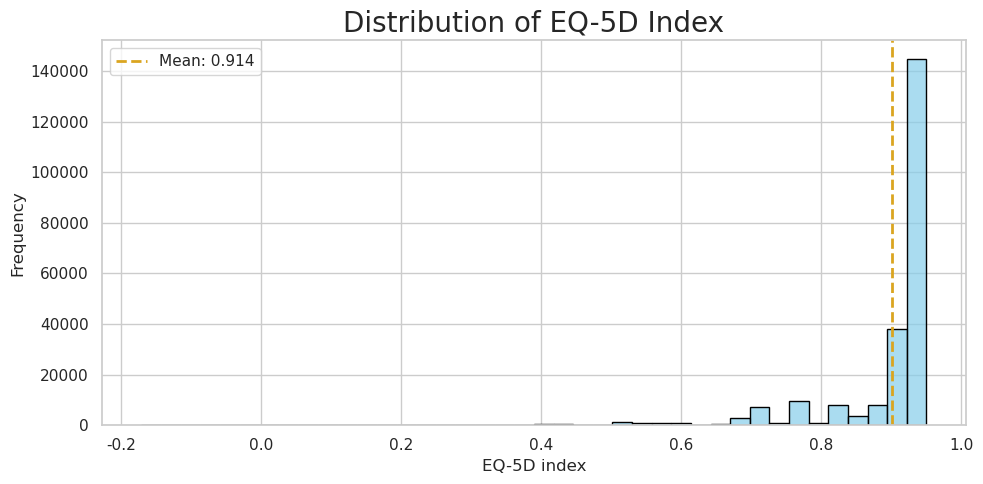

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(10, 5))

# Histogram only, KDE 제거
sns.histplot(
    data=df,
    x='eq5d_index',
    bins=40,
    kde=False,  # KDE 제거
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

# 평균 계산
eq5d_mean = df['eq5d_index'].mean()

# 평균선 추가 (짙은 노란색 점선)
plt.axvline(eq5d_mean, color='goldenrod', linestyle='--', linewidth=2, 
            label=f'Mean: 0.914')

plt.title('Distribution of EQ-5D Index', fontsize=20)
plt.xlabel('EQ-5D index')
plt.ylabel('Frequency')
plt.legend()

# Disable scientific notation if needed
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

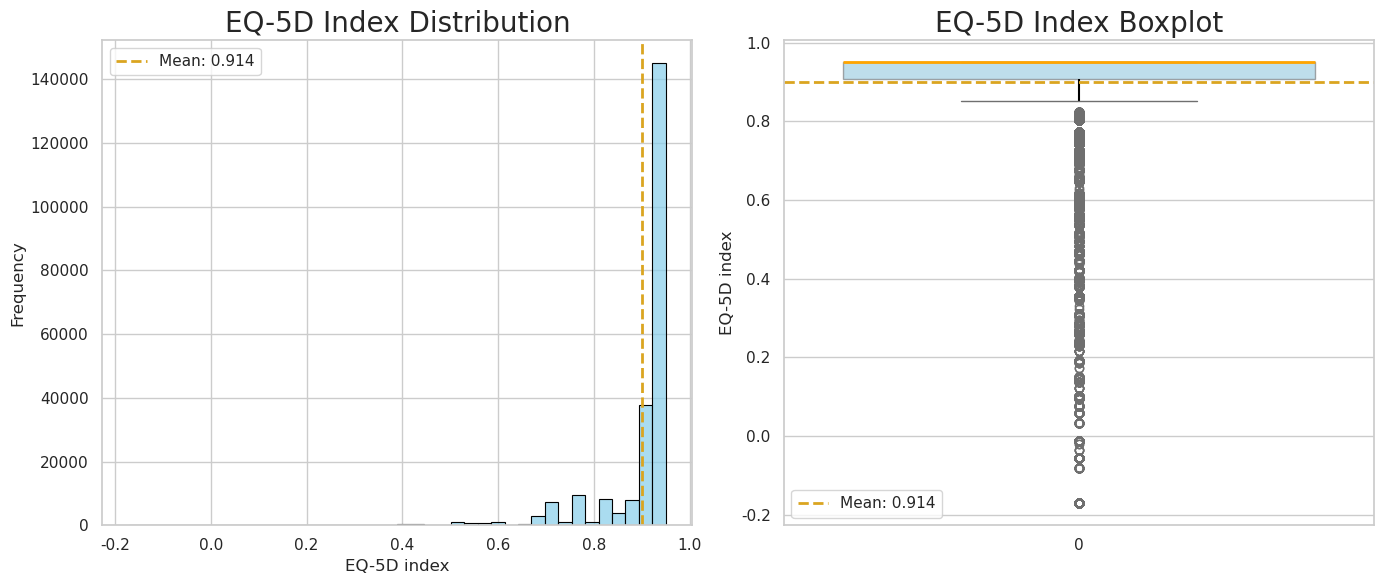

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter

# EQ-5D 평균 계산
eq5d_mean = df['eq5d_index'].mean()

# -------------------------------
# 히스토그램 + 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 히스토그램 (왼쪽)
sns.histplot(
    data=df,
    x='eq5d_index',
    bins=40,
    kde=False,
    color='skyblue',
    edgecolor='black',
    alpha=0.7,
    ax=axes[0]
)
axes[0].axvline(eq5d_mean, color='goldenrod', linestyle='--', linewidth=2,
                label=f'Mean: 0.914')
axes[0].set_title('EQ-5D Index Distribution', fontsize=20)
axes[0].set_xlabel('EQ-5D index')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 박스플롯 (오른쪽)
sns.boxplot(
    y=df['eq5d_index'],
    color='skyblue',
    ax=axes[1],
    boxprops=dict(alpha=0.6),
    medianprops=dict(color='orange', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.5)
)
axes[1].axhline(eq5d_mean, color='goldenrod', linestyle='--', linewidth=2,
                label=f'Mean: 0.914')
axes[1].set_title('EQ-5D Index Boxplot', fontsize=20)
axes[1].set_ylabel('EQ-5D index')
axes[1].legend()

# X, Y축 과학적 표기 제거
for ax in axes:
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='x')
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()


In [13]:
summary = pd.DataFrame({
    '전처리 후': df['eq5d_index'].describe(),
})
print(summary)


               전처리 후
count  230911.000000
mean        0.900388
std         0.108034
min        -0.171000
25%         0.907000
50%         0.950000
75%         0.950000
max         0.950000


In [14]:
print("전처리 후 음수 비율:", (df['eq5d_index']<0).mean())


전처리 후 음수 비율: 0.002135021718324376


###3가지 하나의 피겨 ( 히스토그램, 박스플롯, 평균, 전처리 후 음수 비율)

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
C:\Users\asia\AppData\Local\Temp\ipykernel_13728\1421991147.py:29: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asia\AppData\Local\Temp\ipykernel_13728\1421991147.py:29: UserWar

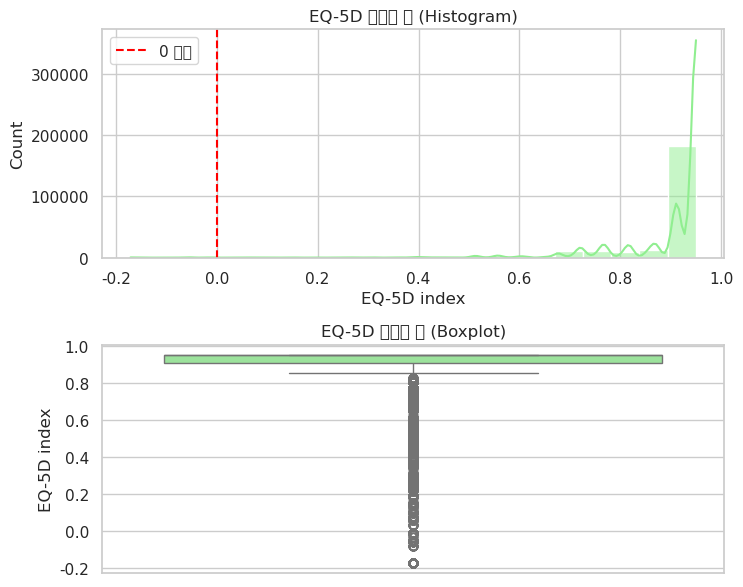

전처리 후 음수 비율: 0.214%


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic')  # NanumGothic 설치 필요
plt.rc('axes', unicode_minus=False)    # 마이너스 깨짐 방지

# Figure 설정
plt.figure(figsize=(14,6))

# -----------------------------
# 2) 히스토그램: 전처리 후
plt.subplot(2,2,2)
sns.histplot(df['eq5d_index'], bins=20, kde=True, color='lightgreen')
plt.title("EQ-5D 전처리 후 (Histogram)")
plt.xlabel("EQ-5D index")
plt.ylabel("Count")
plt.axvline(0, color='red', linestyle='--', label="0 기준")
plt.legend()

# -----------------------------

# 4) 박스플롯: 전처리 후
plt.subplot(2,2,4)
sns.boxplot(y=df['eq5d_index'], color='lightgreen')
plt.title("EQ-5D 전처리 후 (Boxplot)")
plt.ylabel("EQ-5D index")

plt.tight_layout()
plt.show()

# -----------------------------
# 음수 비율 출력 (텍스트로)
neg_processed = (df['eq5d_index'] < 0).mean()
print(f"전처리 후 음수 비율: {neg_processed:.3%}")


# 전처리 후 연소득 시각화

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

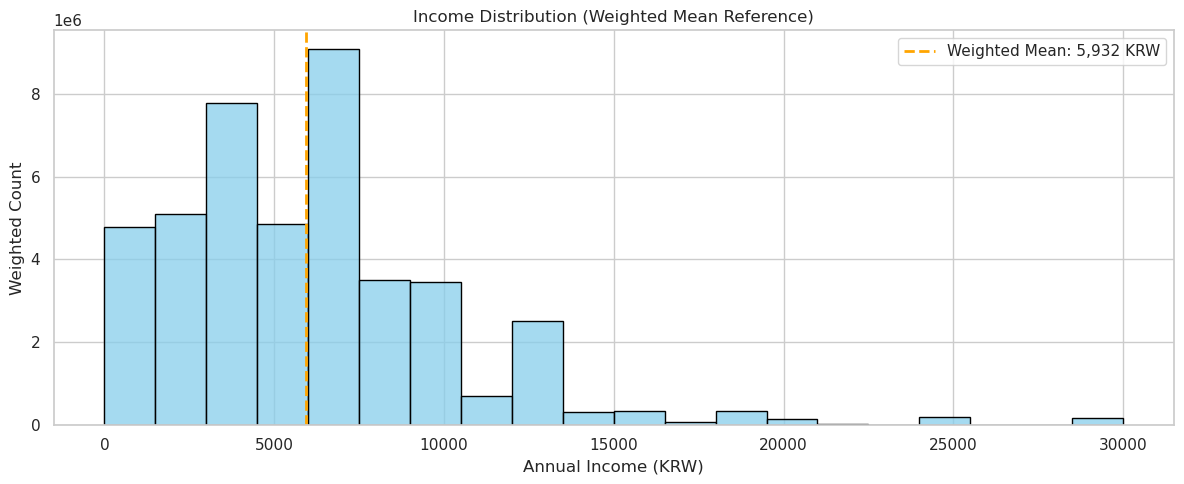

Weighted mean income: 5,932 KRW
Weighted sum by mean-based group:
income_group
Above or Equal to Mean    2.090848e+07
Below Mean                2.252578e+07
Name: wt_p, dtype: float64


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set font (optional, for Windows users)
plt.rc('axes', unicode_minus=False)

# df 사용, income_year_final 변수
income = df['income_year_final']

# -------------------------------
# Weighted mean calculation (rounded)
income_mean_w = round(np.average(income, weights=df['wt_p']))

# Mean-based grouping
df['income_group'] = np.where(income >= income_mean_w, 'Above or Equal to Mean', 'Below Mean')

# -------------------------------
# Histogram (KDE 제거)
plt.figure(figsize=(12,5))
sns.histplot(df, x='income_year_final', bins=20, weights=df['wt_p'], kde=False,  # kde=False로 변경
             color='skyblue', edgecolor='black')
plt.axvline(income_mean_w, color='orange', linestyle='--', linewidth=2, 
            label=f"Weighted Mean: {income_mean_w:,} KRW")
plt.title("Income Distribution (Weighted Mean Reference)")
plt.xlabel("Annual Income (KRW)")
plt.ylabel("Weighted Count")
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------
# Summary by group
print(f"Weighted mean income: {income_mean_w:,} KRW")
print("Weighted sum by mean-based group:")
print(df.groupby('income_group')['wt_p'].sum())


# 우울점수 (PHQ-9) 분포 시각화

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

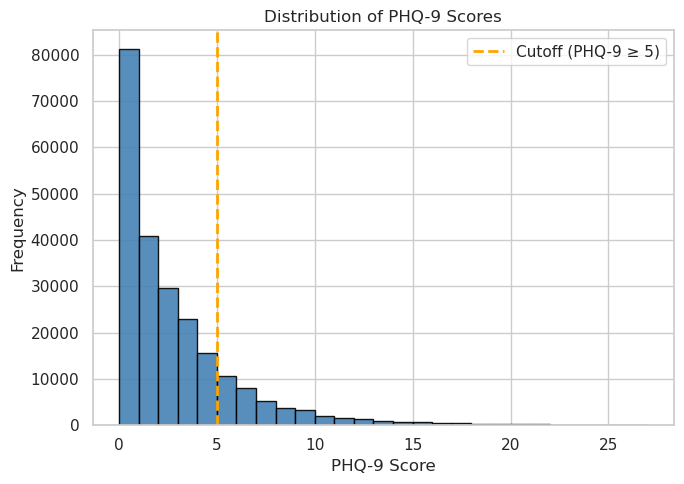

In [24]:
import matplotlib.pyplot as plt

data = df['PHQ9_Score'].dropna()
cutoff = 5

plt.figure(figsize=(7, 5))

plt.hist(
    data,
    bins=27,
    color='steelblue',   # 진한 블루
    alpha=0.9,
    edgecolor='black'
)

plt.axvline(
    cutoff,
    linestyle='--',
    linewidth=2,
    color='orange',
    label='Cutoff (PHQ-9 ≥ 5)'
)

plt.xlabel('PHQ-9 Score')
plt.ylabel('Frequency')
plt.title('Distribution of PHQ-9 Scores')

plt.legend()
plt.tight_layout()
plt.show()


# 파일 변환

In [20]:
df.to_csv( "chs_2024_clean.csv", index=False, encoding="utf-8-sig" )

In [21]:
for col in df.columns:
    print(f"\n[{col}]")
    print(df[col].value_counts(dropna=False))



[EXAMIN_YEAR]
EXAMIN_YEAR
b'2024'    230911
Name: count, dtype: int64

[exmprs_no]
exmprs_no
b'2024503970006201711033102'    1
b'2024111170001700102002101'    1
b'2024111170001700102002102'    1
b'2024111170001700102002201'    1
b'2024111170001700102005901'    1
                               ..
b'2024111170001700712002402'    1
b'2024111170001700712002401'    1
b'2024111170001700712000301'    1
b'2024111170001700191005801'    1
b'2024111170001700191005701'    1
Name: count, Length: 230911, dtype: int64

[age]
age
63.0     6186
64.0     5725
65.0     5485
66.0     5297
62.0     5291
         ... 
101.0      10
102.0       2
109.0       1
106.0       1
103.0       1
Name: count, Length: 87, dtype: int64

[sex]
sex
2.0    125130
1.0    105781
Name: count, dtype: int64

[CTPRVN_CODE]
CTPRVN_CODE
b'41'    43579
b'11'    22631
b'47'    21128
b'46'    19461
b'48'    17922
b'42'    15781
b'26'    14451
b'44'    14327
b'43'    12456
b'45'    12424
b'28'     8973
b'27'     8169
b'50'     4987
